# MC 03 — Forecasting Stability & Stress Tests

Evaluate temporal stability, horizon degradation, and M9W-2023.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "model_comparison.yaml"


In [2]:
import matplotlib.pyplot as plt
from src.ontario_peak_risk.model_comparison.io import load_config, load_model_reports
from src.ontario_peak_risk.model_comparison.metrics import (
    combine_group_metrics,
    forecasting_stability,
    m9w_forecasting_stress,
)
from src.ontario_peak_risk.model_comparison.plotting import m9w_bar_plot

config, project_root = load_config(CONFIG_PATH)
reports = load_model_reports(config, project_root, "forecasting")
fold_table = combine_group_metrics(reports, "fold_metrics")
fsa_table = combine_group_metrics(reports, "fsa_metrics")
horizon_table = combine_group_metrics(reports, "horizon_metrics")

stability = forecasting_stability(fold_table, horizon_table)
m9w_2023 = m9w_forecasting_stress(fsa_table)

display(stability.sort_values("fold_mae_cv"))
display(m9w_2023.sort_values("mae"))


,model,fold_mae_mean,fold_mae_std,fold_mae_cv,fold_mae_range,horizon_mae_slope,short_horizon_mae_h01_h06,long_horizon_mae_h19_h24
3,Seasonal Naive,612.037297,8.245924,0.013473,16.491847,-0.014140,612.176988,611.935396
2,SARIMAX Rolling,583.655604,14.688692,0.025167,29.377384,19.731865,353.600297,714.787501
1,Random Forest Regressor,542.296572,30.232170,0.055748,60.464341,6.635143,465.275552,586.564749
0,LightGBM Regressor,580.986951,110.062969,0.189441,220.125937,10.716403,457.528000,650.361523
4,XGBoost Regressor,606.451442,135.276330,0.223062,270.552659,11.350253,471.395129,676.298633


,model,family,mae,rmse,mape,wape,bias
3,Seasonal Naive,Baseline,841.600423,1332.363841,5.668017,5.902156,-6.180456
1,Random Forest Regressor,Bagging,1188.718257,1775.142021,7.530991,8.336498,-973.423632
2,SARIMAX Rolling,Statistical Time Series,1223.320380,NaN,8.124587,NaN,NaN
0,LightGBM Regressor,Gradient Boosting,1922.876179,NaN,12.776347,NaN,NaN
4,XGBoost Regressor,Gradient Boosting,2158.561949,NaN,14.294676,NaN,NaN


e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


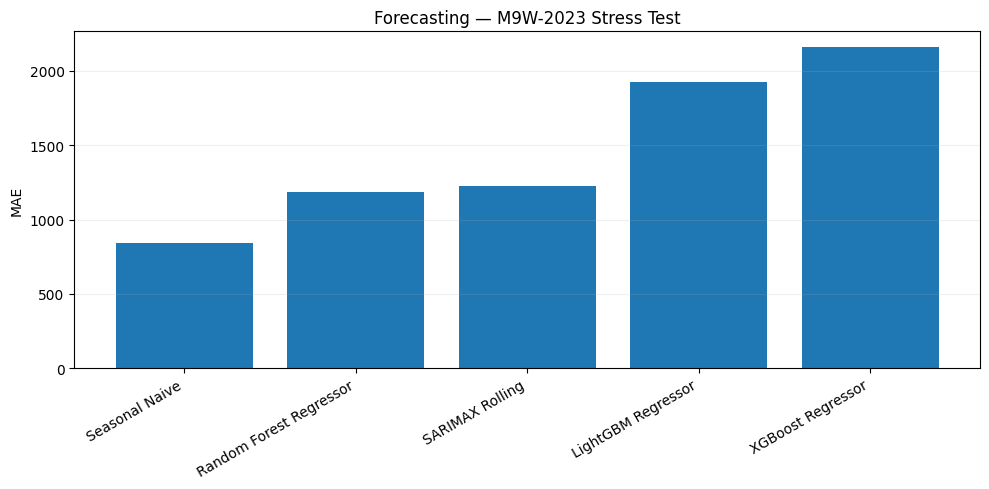

In [3]:
m9w_bar_plot(m9w_2023, "mae", "Forecasting — M9W-2023 Stress Test"); plt.show()